<a href="https://colab.research.google.com/github/palak0626/predictive-analysis/blob/main/multithreading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import threading
import time
import matplotlib.pyplot as plt

In [9]:
NUM_MATRICES = 50
SIZE = 300

In [10]:
matrices = [(np.random.rand(SIZE, SIZE), np.random.rand(SIZE, SIZE)) for _ in range(NUM_MATRICES)]

In [11]:
def multiply_chunk(chunk):
    results = []
    for A, B in chunk:
        results.append(np.dot(A, B))
    return results

In [12]:
def run_threads(num_threads):
    start = time.time()

    chunk_size = len(matrices) // num_threads
    threads = []

    for i in range(num_threads):
        chunk = matrices[i*chunk_size:(i+1)*chunk_size]

        t = threading.Thread(target=multiply_chunk, args=(chunk,))
        threads.append(t)
        t.start()

    for t in threads:
        t.join()

    end = time.time()
    return end - start



In [13]:
thread_counts = [1, 2, 3, 4, 5, 6, 7, 8]
times = []

for t in thread_counts:
    print(f"Running with {t} threads...")
    time_taken = run_threads(t)
    times.append(time_taken)

Running with 1 threads...
Running with 2 threads...
Running with 3 threads...
Running with 4 threads...
Running with 5 threads...
Running with 6 threads...
Running with 7 threads...
Running with 8 threads...


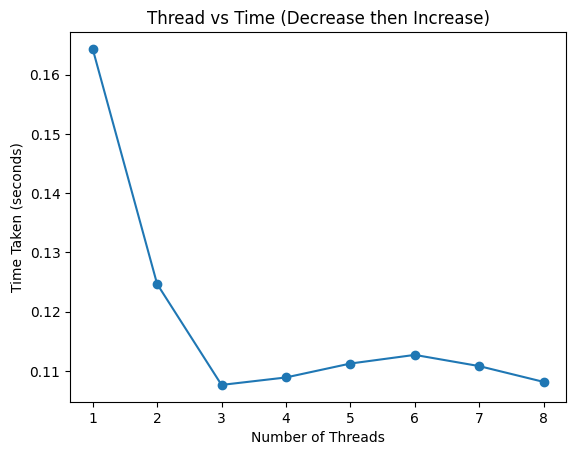

In [14]:
plt.plot(thread_counts, times, marker='o')
plt.xlabel("Number of Threads")
plt.ylabel("Time Taken (seconds)")
plt.title("Thread vs Time (Decrease then Increase)")
plt.show()